## K Means Clustering

K-means is one of the most popular clustering algorithms due to its simplicity and speed. The algorithm partitions the dataset into k clusters, where k is specified in advance. It starts by randomly initializing k cluster centroids, then iteratively assigns each data point to the nearest centroid and updates the centroids based on the mean of points in each cluster. This process continues until convergence, typically when assignments no longer change or the change is below a threshold. However, K-means assumes that clusters are spherical and of roughly equal size, and it is sensitive to the choice of k and the initial placement of centroids.

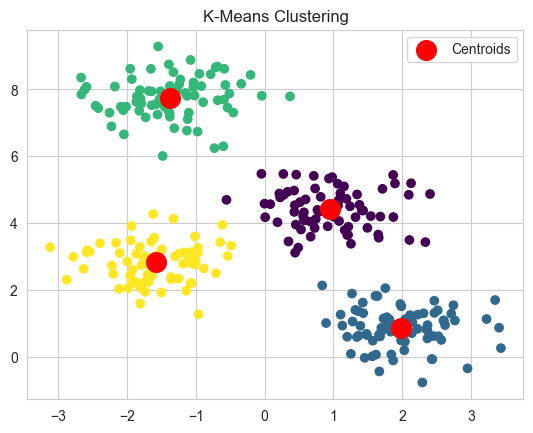

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

kmeans = KMeans(n_clusters=4, random_state=0)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', label='Centroids')
plt.title("K-Means Clustering")
plt.legend()
plt.show()

## Hierarchical Clustering

Hierarchical clustering builds a tree of clusters, called a dendrogram, which helps visualize how data points can be merged or split at different levels of granularity. In agglomerative clustering (bottom-up approach), each data point starts as its own cluster, and pairs of clusters are merged iteratively based on a linkage criterion (e.g., single, complete, or average linkage). Unlike K-means, hierarchical clustering does not require specifying the number of clusters upfront, and the dendrogram can guide where to “cut” the tree to form clusters.

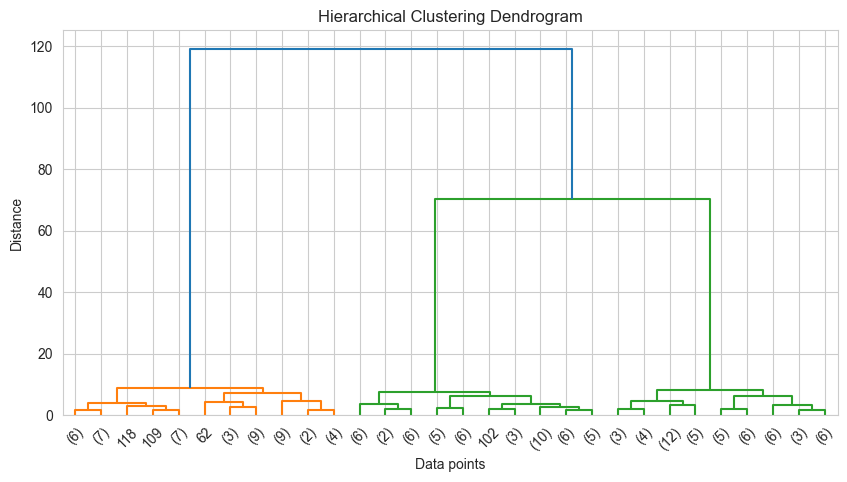

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [4]:
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=42)

linked = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

cluster = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
labels = cluster.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.title("Agglomerative Clustering")
plt.show()

## DBSCAN

DBSCAN groups together data points that are closely packed (points with many nearby neighbors) while marking points in low-density regions as outliers. Unlike K-means, DBSCAN does not require specifying the number of clusters and can discover clusters of arbitrary shape. It uses two key parameters: eps (maximum distance between points in a neighborhood) and min_samples (minimum number of points to form a dense region). DBSCAN is particularly useful for datasets with noise or non-globular cluster shapes but may struggle when clusters have varying densities.

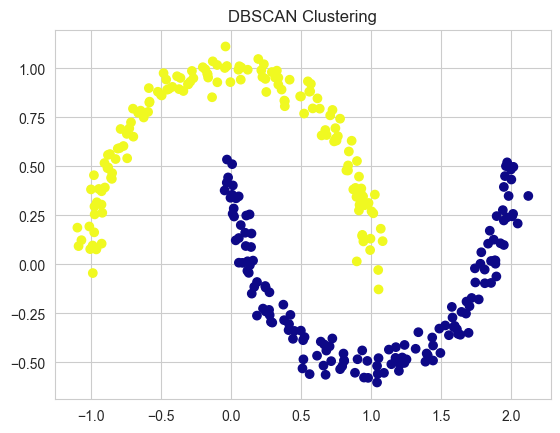

In [5]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.05, random_state=0)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
plt.title("DBSCAN Clustering")
plt.show()

In [6]:
from sklearn.datasets import load_wine
import pandas as pd

data = load_wine(as_frame=True)
X = data.data
y = data.target
feature_names = data.feature_names

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

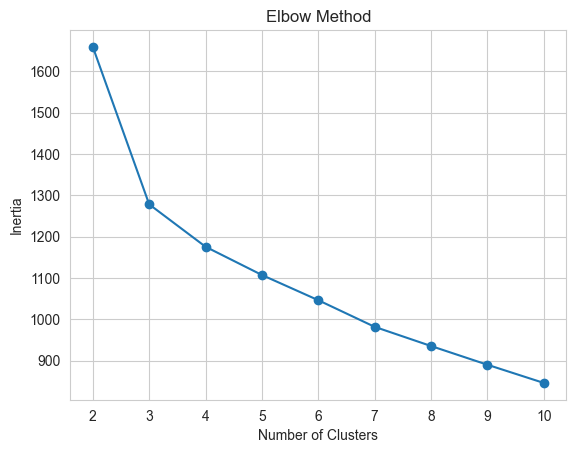

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

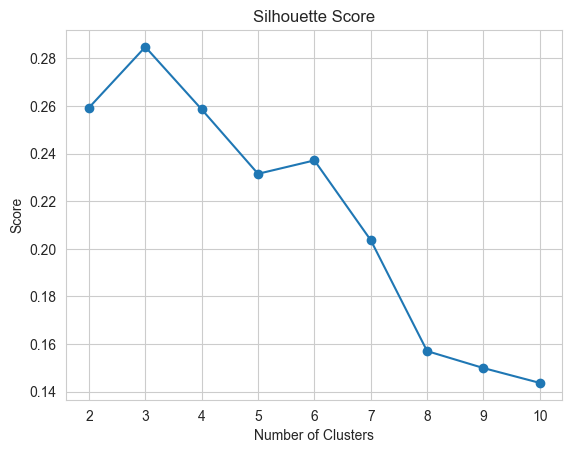

In [9]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

In [10]:
optimal_k = 3

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

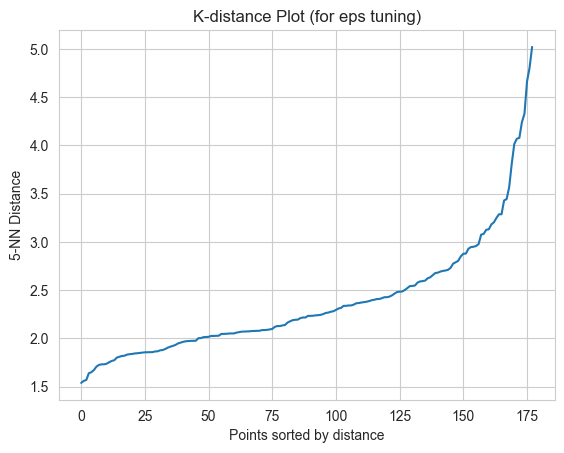

In [12]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure()
plt.plot(distances)
plt.title("K-distance Plot (for eps tuning)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN Distance")
plt.show()

In [13]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.2, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

In [14]:
unique_labels = np.unique(db_labels)

n_clusters = len(unique_labels[unique_labels != -1])
n_noise = list(db_labels).count(-1)

print("DBSCAN clusters:", n_clusters)
print("Noise points:", n_noise)

DBSCAN clusters: 2
Noise points: 55


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

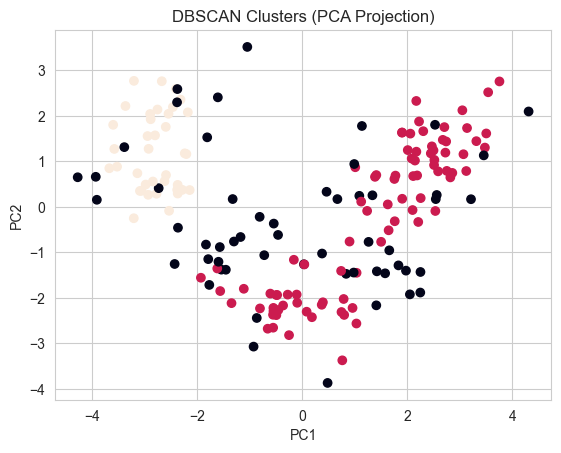

In [16]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

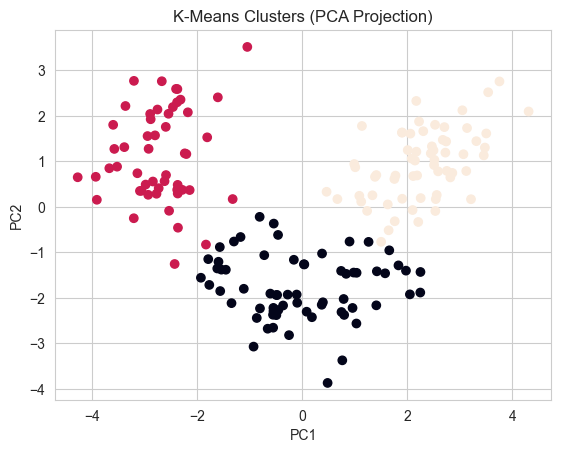

In [18]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [19]:
pd.crosstab(kmeans_labels, db_labels,
            rownames=['KMeans'],
            colnames=['DBSCAN'])

DBSCAN,-1,0,1
KMeans,,,
0,29,36,0
1,14,0,37
2,12,50,0


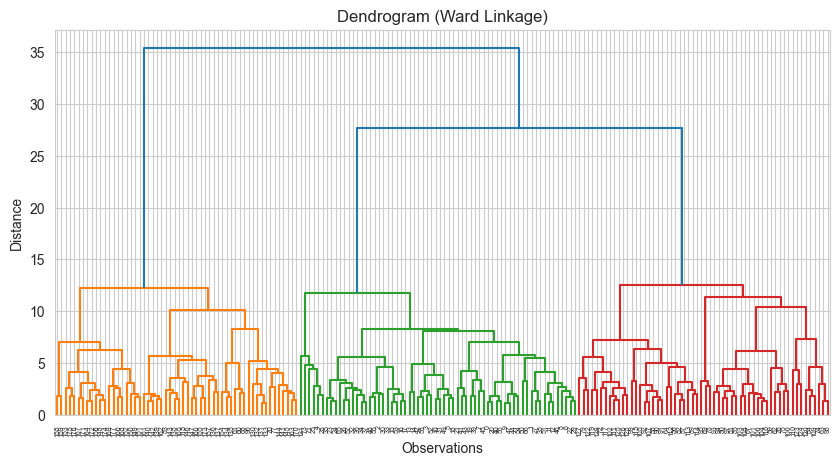

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

In [21]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

agglo_labels = agglo.fit_predict(X_scaled)

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

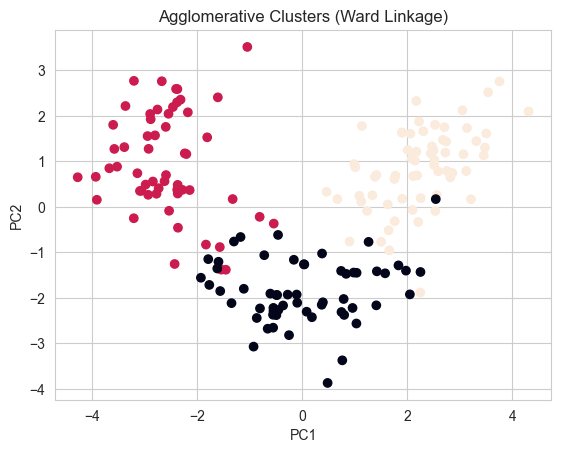

In [23]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=agglo_labels)
plt.title("Agglomerative Clusters (Ward Linkage)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

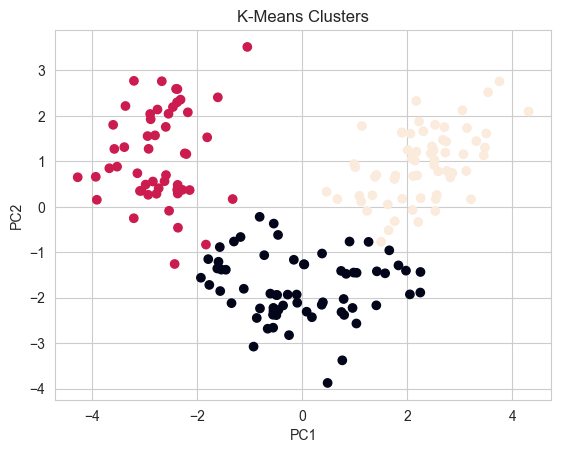

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [25]:
import pandas as pd

pd.crosstab(kmeans_labels, agglo_labels,
            rownames=['KMeans'],
            colnames=['Agglomerative'])

Agglomerative,0,1,2
KMeans,,,
0,57,5,3
1,0,51,0
2,1,0,61


In [26]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(kmeans_labels, agglo_labels)
print("ARI vs KMeans:", ari)

ARI vs KMeans: 0.8529841218194189


# Dimensionality reduction


## UMAP

UMAP is a powerful non-linear dimensionality reduction algorithm designed for both visualization and general-purpose embedding. It builds upon concepts from manifold learning and topological data analysis, aiming to preserve both local and global structures better than t-SNE, especially when reducing to more than two dimensions. UMAP is faster and more scalable than t-SNE, making it suitable for large datasets. It works by constructing a high-dimensional graph representation of the data and then optimizing a low-dimensional projection that preserves the structure. UMAP is widely used in exploratory data analysis, particularly in domains like genomics, NLP embeddings, and clustering.

In [ ]:
import umap
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1,
										n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='Spectral', s=10)
plt.title('UMAP Projection of Digits Dataset')
plt.colorbar()
plt.show()

## NMF

NMF is a linear dimensionality reduction technique that factorizes a non-negative input matrix into two smaller non-negative matrices—often interpreted as parts-based representations. In practice, this makes NMF particularly useful when interpretability is important, such as in text mining (e.g., topic modeling) or image processing. Each data point is expressed as a non-negative combination of basis components, which often leads to sparse and human-interpretable features. Unlike PCA, NMF does not allow negative weights, making it well-suited for cases where components must have a clear additive meaning.

In [1]:
from sklearn.decomposition import NMF
from sklearn.datasets import fetch_20newsgroups_vectorized
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

data = fetch_20newsgroups_vectorized(subset='train')
X = data.data

nmf = NMF(n_components=10, random_state=0)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = data.feature_names_out
for topic_idx, topic in enumerate(H):
    top_features = [feature_names[i] for i in topic.argsort()[:-6:-1]]
    print(f"Topic #{topic_idx + 1}: {' '.join(top_features)}")

/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


AttributeError: feature_names_out

## Evaluation

Clustering evaluation aims to assess the quality of clusters produced by unsupervised algorithms. Since clustering often lacks ground truth labels, internal evaluation metrics are commonly used. These metrics quantify how well the clusters are separated and how compact they are, based solely on the data and the cluster assignments. For example, the Silhouette Score measures the similarity of each point to its own cluster compared to other clusters, with values near 1 indicating well-defined clusters. The Davies-Bouldin Index evaluates the average similarity between each cluster and its most similar one, where lower values correspond to better clustering. Internal metrics help guide parameter tuning (e.g., choosing the number of clusters) when labels are unavailable.

When true labels are known, external evaluation metrics provide a way to compare the clustering results against the ground truth. These metrics, such as the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI), measure the agreement between predicted clusters and actual classes, correcting for chance grouping. ARI ranges from -1 to 1, with 1 meaning perfect clustering, while NMI measures mutual dependence between cluster assignments and true labels on a scale from 0 to 1. External metrics are useful for benchmarking clustering algorithms on labeled datasets, but are not applicable in fully unsupervised scenarios.

In [ ]:
# Measures cohesion and separation by comparing the average intra-cluster distance to the nearest-cluster distance for each sample. Higher is better (max 1).

from sklearn.metrics import silhouette_score

score = silhouette_score(X, cluster_labels)
print(f'Silhouette Score: {score:.3f}')

In [ ]:
# Computes average similarity between clusters based on intra-cluster distances and inter-cluster separation. Lower is better (min 0).

from sklearn.metrics import davies_bouldin_score

score = davies_bouldin_score(X, cluster_labels)
print(f'Davies-Bouldin Index: {score:.3f}')

In [ ]:
# Measures similarity between predicted clusters and ground truth labels, adjusted for chance. Range: -1 to 1; 1 = perfect match.

from sklearn.metrics import adjusted_rand_score

score = adjusted_rand_score(true_labels, cluster_labels)
print(f'Adjusted Rand Index: {score:.3f}')

In [ ]:
# Quantifies mutual information between clustering and true labels, normalized between 0 (no mutual information) and 1 (perfect correlation).

from sklearn.metrics import normalized_mutual_info_score

score = normalized_mutual_info_score(true_labels, cluster_labels)
print(f'Normalized Mutual Information: {score:.3f}')

### Exercise

In [ ]:
# 0) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

# UMAP is optional (pip install umap-learn)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False


# 1) Load and explore data
data = load_wine(as_frame=True)
X = data.data
y = data.target.to_numpy()
feature_names = data.feature_names

print("Shape:", X.shape)
print("Classes:", np.unique(y), "counts:", np.bincount(y))

df = X.copy()
df["target"] = y
print("\nHead:\n", df.head())
print("\nDescribe (features):\n", X.describe().T)


# 1b) Standardize features (for PCA / t-SNE / UMAP)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# For NMF (must be non-negative): scale to [0, 1]
mm = MinMaxScaler()
X_mm = mm.fit_transform(X)


# 2) 2D dimensionality reduction
embeddings = {}

# PCA
pca = PCA(n_components=2, random_state=42)
embeddings["PCA"] = pca.fit_transform(X_std)

# t-SNE (stochastic; results vary with random_state & hyperparams)
tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=30,   # tune 5–50
    n_iter=1000
)
embeddings["t-SNE"] = tsne.fit_transform(X_std)

# UMAP (if available)
if UMAP_AVAILABLE:
    reducer = umap.UMAP(
        n_components=2,
        random_state=42,
        n_neighbors=15,  # tune 5–50
        min_dist=0.1     # tune 0.0–0.8
    )
    embeddings["UMAP"] = reducer.fit_transform(X_std)
else:
    print("\nUMAP not installed. Run: pip install umap-learn")

# NMF (on MinMax-scaled non-negative data)
nmf = NMF(n_components=2, init="nndsvda", random_state=42, max_iter=2000)
embeddings["NMF"] = nmf.fit_transform(X_mm)


# 3) KMeans clustering on each 2D embedding + visualization
kmeans_labels = {}
fig, axes = plt.subplots(1, len(embeddings), figsize=(4*len(embeddings), 4), constrained_layout=True)

if len(embeddings) == 1:
    axes = [axes]

for ax, (name, Z) in zip(axes, embeddings.items()):
    km = KMeans(n_clusters=3, random_state=42, n_init=20)
    labels = km.fit_predict(Z)
    kmeans_labels[name] = labels

    ax.scatter(Z[:, 0], Z[:, 1], c=labels, s=25)
    ax.set_title(f"{name} + KMeans(k=3)")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.show()


# (Optional but useful) Show true labels in same projections
fig, axes = plt.subplots(1, len(embeddings), figsize=(4*len(embeddings), 4), constrained_layout=True)
if len(embeddings) == 1:
    axes = [axes]

for ax, (name, Z) in zip(axes, embeddings.items()):
    ax.scatter(Z[:, 0], Z[:, 1], c=y, s=25)
    ax.set_title(f"{name} (true classes)")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.show()


# 4) Evaluation metrics (internal + external)
rows = []
for name, Z in embeddings.items():
    labels = kmeans_labels[name]

    rows.append({
        "Method": name,
        "Silhouette (↑)": silhouette_score(Z, labels),
        "Davies-Bouldin (↓)": davies_bouldin_score(Z, labels),
        "ARI (↑)": adjusted_rand_score(y, labels),
        "NMI (↑)": normalized_mutual_info_score(y, labels),
    })

results = pd.DataFrame(rows).set_index("Method").sort_index()
print("\nEvaluation summary:\n", results.round(3))


# 5) Summary chart / table
# Table
display(results.round(3))

# Quick bar chart (ARI + Silhouette)
ax = results[["ARI (↑)", "Silhouette (↑)"]].plot(kind="bar", figsize=(8, 4))
ax.set_title("Clustering quality on each 2D projection")
ax.set_xlabel("Projection method")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

PCA
Preserves global variance (linear). Often gives “okay” separation but can mix classes if clusters are nonlinear.

t-SNE
Usually produces visually separated blobs because it preserves local neighborhoods very strongly.
Trade-off: distances/cluster sizes between blobs are not globally meaningful, and results can vary across runs/hyperparams.

UMAP
Often a strong middle ground: tends to preserve local structure like t-SNE but keeps more global structure. Frequently performs well for clustering on embeddings.

NMF
More interpretable because it’s additive (parts-based) but you must keep input non-negative (hence MinMax scaling). Can work well if the data is well-explained by additive components; may underperform if separation needs nonlinear geometry.

PCA
Preserves global variance (linear). Often gives “okay” separation but can mix classes if clusters are nonlinear.

t-SNE
Usually produces visually separated blobs because it preserves local neighborhoods very strongly.
Trade-off: distances/cluster sizes between blobs are not globally meaningful, and results can vary across runs/hyperparams.

UMAP
Often a strong middle ground: tends to preserve local structure like t-SNE but keeps more global structure. Frequently performs well for clustering on embeddings.

NMF
More interpretable because it’s additive (parts-based) but you must keep input non-negative (hence MinMax scaling). Can work well if the data is well-explained by additive components; may underperform if separation needs nonlinear geometry.